In [214]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import pickle

In [215]:
df = pd.read_csv("earthquake_cleaned.csv")

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,longitude,location,continent,country,Year,Month,Day,Hour,Damage_Level,Risk_Score
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,167.1580,"Sola, Vanuatu",NaN,Vanuatu,2023,8,16,12,High,6.107
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,-88.1265,"Intipucá, El Salvador",NaN,NaN,2023,7,19,0,High,6.825
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,-70.3731,"Loncopué, Argentina",South America,Argentina,2023,7,17,3,High,6.599
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,-160.6990,"Sand Point, Alaska",NaN,NaN,2023,7,16,6,Severe,6.860
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,NaN,1,820,at,79,...,-160.7960,Alaska Peninsula,NaN,NaN,2023,7,16,6,Moderate,5.470


In [216]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1000
Columns : 25


In [217]:
df.isnull().sum()

title             0
magnitude         0
date_time         0
cdi               0
mmi               0
alert           551
tsunami           0
sig               0
net               0
nst               0
dmin              0
gap               0
magType           0
depth             0
latitude          0
longitude         0
location          6
continent       716
country         349
Year              0
Month             0
Day               0
Hour              0
Damage_Level      0
Risk_Score        0
dtype: int64

In [218]:
num_cols=df.select_dtypes(include=np.number).columns

cat_cols=df.select_dtypes(include="object").columns

for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

In [219]:
df.isnull().sum().sum()

np.int64(0)

In [220]:
bins=[0,4,5,6.5,10]

labels=["Low","Moderate","High","Severe"]

df["Magnitude_Category"]=pd.cut(
    df["magnitude"],
    bins=bins,
    labels=labels
)

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,location,continent,country,Year,Month,Day,Hour,Damage_Level,Risk_Score,Magnitude_Category
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,"Sola, Vanuatu",Asia,Vanuatu,2023,8,16,12,High,6.107,High
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,"Intipucá, El Salvador",Asia,Indonesia,2023,7,19,0,High,6.825,High
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,"Loncopué, Argentina",South America,Argentina,2023,7,17,3,High,6.599,Severe
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,"Sand Point, Alaska",Asia,Indonesia,2023,7,16,6,Severe,6.860,Severe
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,green,1,820,at,79,...,Alaska Peninsula,Asia,Indonesia,2023,7,16,6,Moderate,5.470,Severe


In [221]:
depth_bins=[-1,70,300,1000]

depth_labels=["Shallow","Intermediate","Deep"]

df["Depth_Category"]=pd.cut(
    df["depth"],
    bins=depth_bins,
    labels=depth_labels
)

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,continent,country,Year,Month,Day,Hour,Damage_Level,Risk_Score,Magnitude_Category,Depth_Category
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,Asia,Vanuatu,2023,8,16,12,High,6.107,High,Intermediate
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,Asia,Indonesia,2023,7,19,0,High,6.825,High,Shallow
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,South America,Argentina,2023,7,17,3,High,6.599,Severe,Intermediate
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,Asia,Indonesia,2023,7,16,6,Severe,6.860,Severe,Shallow
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,green,1,820,at,79,...,Asia,Indonesia,2023,7,16,6,Moderate,5.470,Severe,Shallow


In [222]:
df["Energy_Index"]=10**(1.5*df["magnitude"])

In [223]:
df["Risk_Score"]=(
    df["magnitude"]*0.5+
    df["mmi"]*0.2+
    df["cdi"]*0.2+
    df["sig"]/1000
)

In [224]:
df["Tsunami_Flag"]=df["tsunami"].astype(int)

In [225]:
df["High_Alert"]=df["alert"].isin(
    ["orange","red"]
).astype(int)

In [226]:
current_year=2026

df["Years_Ago"]=current_year-df["Year"]

In [227]:
drop_cols=[
    "title",
    "location",
    "date_time"
]

df.drop(columns=drop_cols,
        inplace=True,
        errors="ignore")

In [228]:
df.head()

,magnitude,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,...,Day,Hour,Damage_Level,Risk_Score,Magnitude_Category,Depth_Category,Energy_Index,Tsunami_Flag,High_Alert,Years_Ago
0,6.5,7,4,green,0,657,us,114,7.177000,25.0,...,16,12,High,6.107,High,Intermediate,5.623413e+09,0,0,3
1,6.5,8,6,yellow,0,775,us,92,0.679000,40.0,...,19,0,High,6.825,High,Shallow,5.623413e+09,0,0,3
2,6.6,7,5,green,0,899,us,70,1.634000,28.0,...,17,3,High,6.599,Severe,Intermediate,7.943282e+09,0,0,3
3,7.2,6,6,green,1,860,us,173,0.907000,36.0,...,16,6,Severe,6.860,Severe,Shallow,6.309573e+10,1,0,3
4,7.3,0,5,green,1,820,at,79,0.879451,172.8,...,16,6,Moderate,5.470,Severe,Shallow,8.912509e+10,1,0,3


In [229]:
X = df.drop(columns=["Damage_Level", "Risk_Score"])

y = df["Damage_Level"]

In [230]:
y.value_counts()

Damage_Level
Low         258
Severe      250
High        248
Moderate    244
Name: count, dtype: int64

In [231]:
cat_features=X.select_dtypes(include="object").columns

num_features=X.select_dtypes(exclude="object").columns

print(cat_features)

print(num_features)

Index(['alert', 'net', 'magType', 'continent', 'country'], dtype='object')
Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude', 'Year', 'Month', 'Day', 'Hour',
       'Magnitude_Category', 'Depth_Category', 'Energy_Index', 'Tsunami_Flag',
       'High_Alert', 'Years_Ago'],
      dtype='object')


In [232]:
ohe=OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [233]:
scaler=StandardScaler()

In [234]:
cat_features = X.select_dtypes(include=["object", "category"]).columns

num_features = X.select_dtypes(include=np.number).columns

print("Categorical:")
print(cat_features)

print("\nNumerical:")
print(num_features)

Categorical:
Index(['alert', 'net', 'magType', 'continent', 'country', 'Magnitude_Category',
       'Depth_Category'],
      dtype='object')

Numerical:
Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude', 'Year', 'Month', 'Day', 'Hour',
       'Energy_Index', 'Tsunami_Flag', 'High_Alert', 'Years_Ago'],
      dtype='object')


In [235]:
preprocessor=ColumnTransformer(

    transformers=[

        ("cat",ohe,cat_features),

        ("num",scaler,num_features)

    ]

)

In [236]:
print(X.dtypes)

magnitude              float64
cdi                      int64
mmi                      int64
alert                   object
tsunami                  int64
sig                      int64
net                     object
nst                      int64
dmin                   float64
gap                    float64
magType                 object
depth                  float64
latitude               float64
longitude              float64
continent               object
country                 object
Year                     int64
Month                    int64
Day                      int64
Hour                     int64
Magnitude_Category    category
Depth_Category        category
Energy_Index           float64
Tsunami_Flag             int64
High_Alert               int64
Years_Ago                int64
dtype: object


In [237]:
X_processed=preprocessor.fit_transform(X)

In [238]:
print(X_processed.shape)

(1000, 110)


In [239]:
print(y.value_counts())

Damage_Level
Low         258
Severe      250
High        248
Moderate    244
Name: count, dtype: int64


In [240]:
print(y.unique())

['High' 'Severe' 'Moderate' 'Low']


In [241]:
print(le.classes_)

['High' 'Low' 'Moderate' 'Severe']


In [242]:
le=LabelEncoder()

y_encoded=le.fit_transform(y)

y_encoded[:10]

array([0, 0, 0, 3, 2, 2, 2, 3, 0, 2])

In [243]:
le.classes_

array(['High', 'Low', 'Moderate', 'Severe'], dtype=object)

In [244]:
X_train,X_test,y_train,y_test=train_test_split(

    X_processed,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded

)

In [245]:
print(X_train.shape)

print(X_test.shape)

(800, 110)
(200, 110)


In [246]:
pickle.dump(
    preprocessor,
    open("preprocessor.pkl","wb")
)

pickle.dump(
    le,
    open("label_encoder.pkl","wb")
)

print("Saved Successfully")

Saved Successfully


In [247]:
feature_names=preprocessor.get_feature_names_out()

feature_names

array(['cat__alert_green', 'cat__alert_orange', 'cat__alert_red',
       'cat__alert_yellow', 'cat__net_ak', 'cat__net_at', 'cat__net_ci',
       'cat__net_duputel', 'cat__net_hv', 'cat__net_nc', 'cat__net_nn',
       'cat__net_official', 'cat__net_pt', 'cat__net_us', 'cat__net_uw',
       'cat__magType_Mi', 'cat__magType_mb', 'cat__magType_md',
       'cat__magType_ml', 'cat__magType_ms', 'cat__magType_mw',
       'cat__magType_mwb', 'cat__magType_mwc', 'cat__magType_mww',
       'cat__continent_Africa', 'cat__continent_Asia',
       'cat__continent_Europe', 'cat__continent_North America',
       'cat__continent_Oceania', 'cat__continent_South America',
       'cat__country_Afghanistan', 'cat__country_Algeria',
       'cat__country_Antarctica', 'cat__country_Argentina',
       'cat__country_Azerbaijan', 'cat__country_Bolivia',
       'cat__country_Botswana', 'cat__country_Brazil',
       'cat__country_Canada', 'cat__country_Chile',
       'cat__country_Colombia', 'cat__country_Costa R

In [248]:
X_df=pd.DataFrame(
    X_processed,
    columns=feature_names
)

X_df.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__latitude,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.683582,0.985112,1.582253,0.40483,0.083822,0.013187,-0.106398,-0.693889,-0.196014,-1.582253
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.319250,-1.189010,1.582253,0.11792,0.438001,-1.725784,-0.106398,-0.693889,-0.196014,-1.582253
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.596794,-1.037814,1.582253,0.11792,0.201882,-1.291041,-0.105297,-0.693889,-0.196014,-1.582253
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.880873,-1.807072,1.582253,0.11792,0.083822,-0.856298,-0.079118,1.441153,-0.196014,-1.582253
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.884840,-1.807898,1.582253,0.11792,0.083822,-0.856298,-0.066762,1.441153,-0.196014,-1.582253


In [249]:
processed_df=X_df.copy()

processed_df["Damage_Level"]=y_encoded

processed_df.to_csv(
    "processed_dataset.csv",
    index=False
)

In [250]:
corr=processed_df.corr()

corr.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
cat__alert_green,1.000000,-0.481204,-0.352178,-0.768387,-0.022536,0.017876,-0.106261,0.017876,-0.061392,0.017876,...,0.059595,-0.301864,0.016113,-0.038537,0.039975,-0.007413,-0.201480,-0.601501,0.301864,-0.293109
cat__alert_orange,-0.481204,1.000000,-0.017997,-0.039266,0.039685,-0.008602,-0.008602,-0.008602,-0.007020,-0.008602,...,-0.028573,0.152987,-0.015252,0.014687,0.010590,0.000841,0.058590,0.800006,-0.152987,0.211287
cat__alert_red,-0.352178,-0.017997,1.000000,-0.028737,-0.013171,-0.006295,0.155126,-0.006295,-0.005138,-0.006295,...,-0.023339,0.099113,0.000869,0.011704,-0.043263,0.003883,0.014608,0.585498,-0.099113,0.154634
cat__alert_yellow,-0.768387,-0.039266,-0.028737,1.000000,0.008730,-0.013735,0.063866,-0.013735,0.083785,-0.013735,...,-0.044730,0.230387,-0.010656,0.033014,-0.036059,0.006855,0.206822,-0.049082,-0.230387,0.154882
cat__net_ak,-0.022536,0.039685,-0.013171,0.008730,1.000000,-0.006295,-0.006295,-0.006295,-0.005138,-0.006295,...,-0.199076,0.000571,0.013533,0.025254,-0.008721,0.000500,0.033456,0.024273,-0.000571,0.036001


In [251]:
processed_df=X_df.copy()

processed_df["Damage_Level"]=y_encoded

processed_df.to_csv(
    "processed_dataset.csv",
    index=False
)

In [252]:
corr=processed_df.corr()

corr.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
cat__alert_green,1.000000,-0.481204,-0.352178,-0.768387,-0.022536,0.017876,-0.106261,0.017876,-0.061392,0.017876,...,0.059595,-0.301864,0.016113,-0.038537,0.039975,-0.007413,-0.201480,-0.601501,0.301864,-0.293109
cat__alert_orange,-0.481204,1.000000,-0.017997,-0.039266,0.039685,-0.008602,-0.008602,-0.008602,-0.007020,-0.008602,...,-0.028573,0.152987,-0.015252,0.014687,0.010590,0.000841,0.058590,0.800006,-0.152987,0.211287
cat__alert_red,-0.352178,-0.017997,1.000000,-0.028737,-0.013171,-0.006295,0.155126,-0.006295,-0.005138,-0.006295,...,-0.023339,0.099113,0.000869,0.011704,-0.043263,0.003883,0.014608,0.585498,-0.099113,0.154634
cat__alert_yellow,-0.768387,-0.039266,-0.028737,1.000000,0.008730,-0.013735,0.063866,-0.013735,0.083785,-0.013735,...,-0.044730,0.230387,-0.010656,0.033014,-0.036059,0.006855,0.206822,-0.049082,-0.230387,0.154882
cat__net_ak,-0.022536,0.039685,-0.013171,0.008730,1.000000,-0.006295,-0.006295,-0.006295,-0.005138,-0.006295,...,-0.199076,0.000571,0.013533,0.025254,-0.008721,0.000500,0.033456,0.024273,-0.000571,0.036001


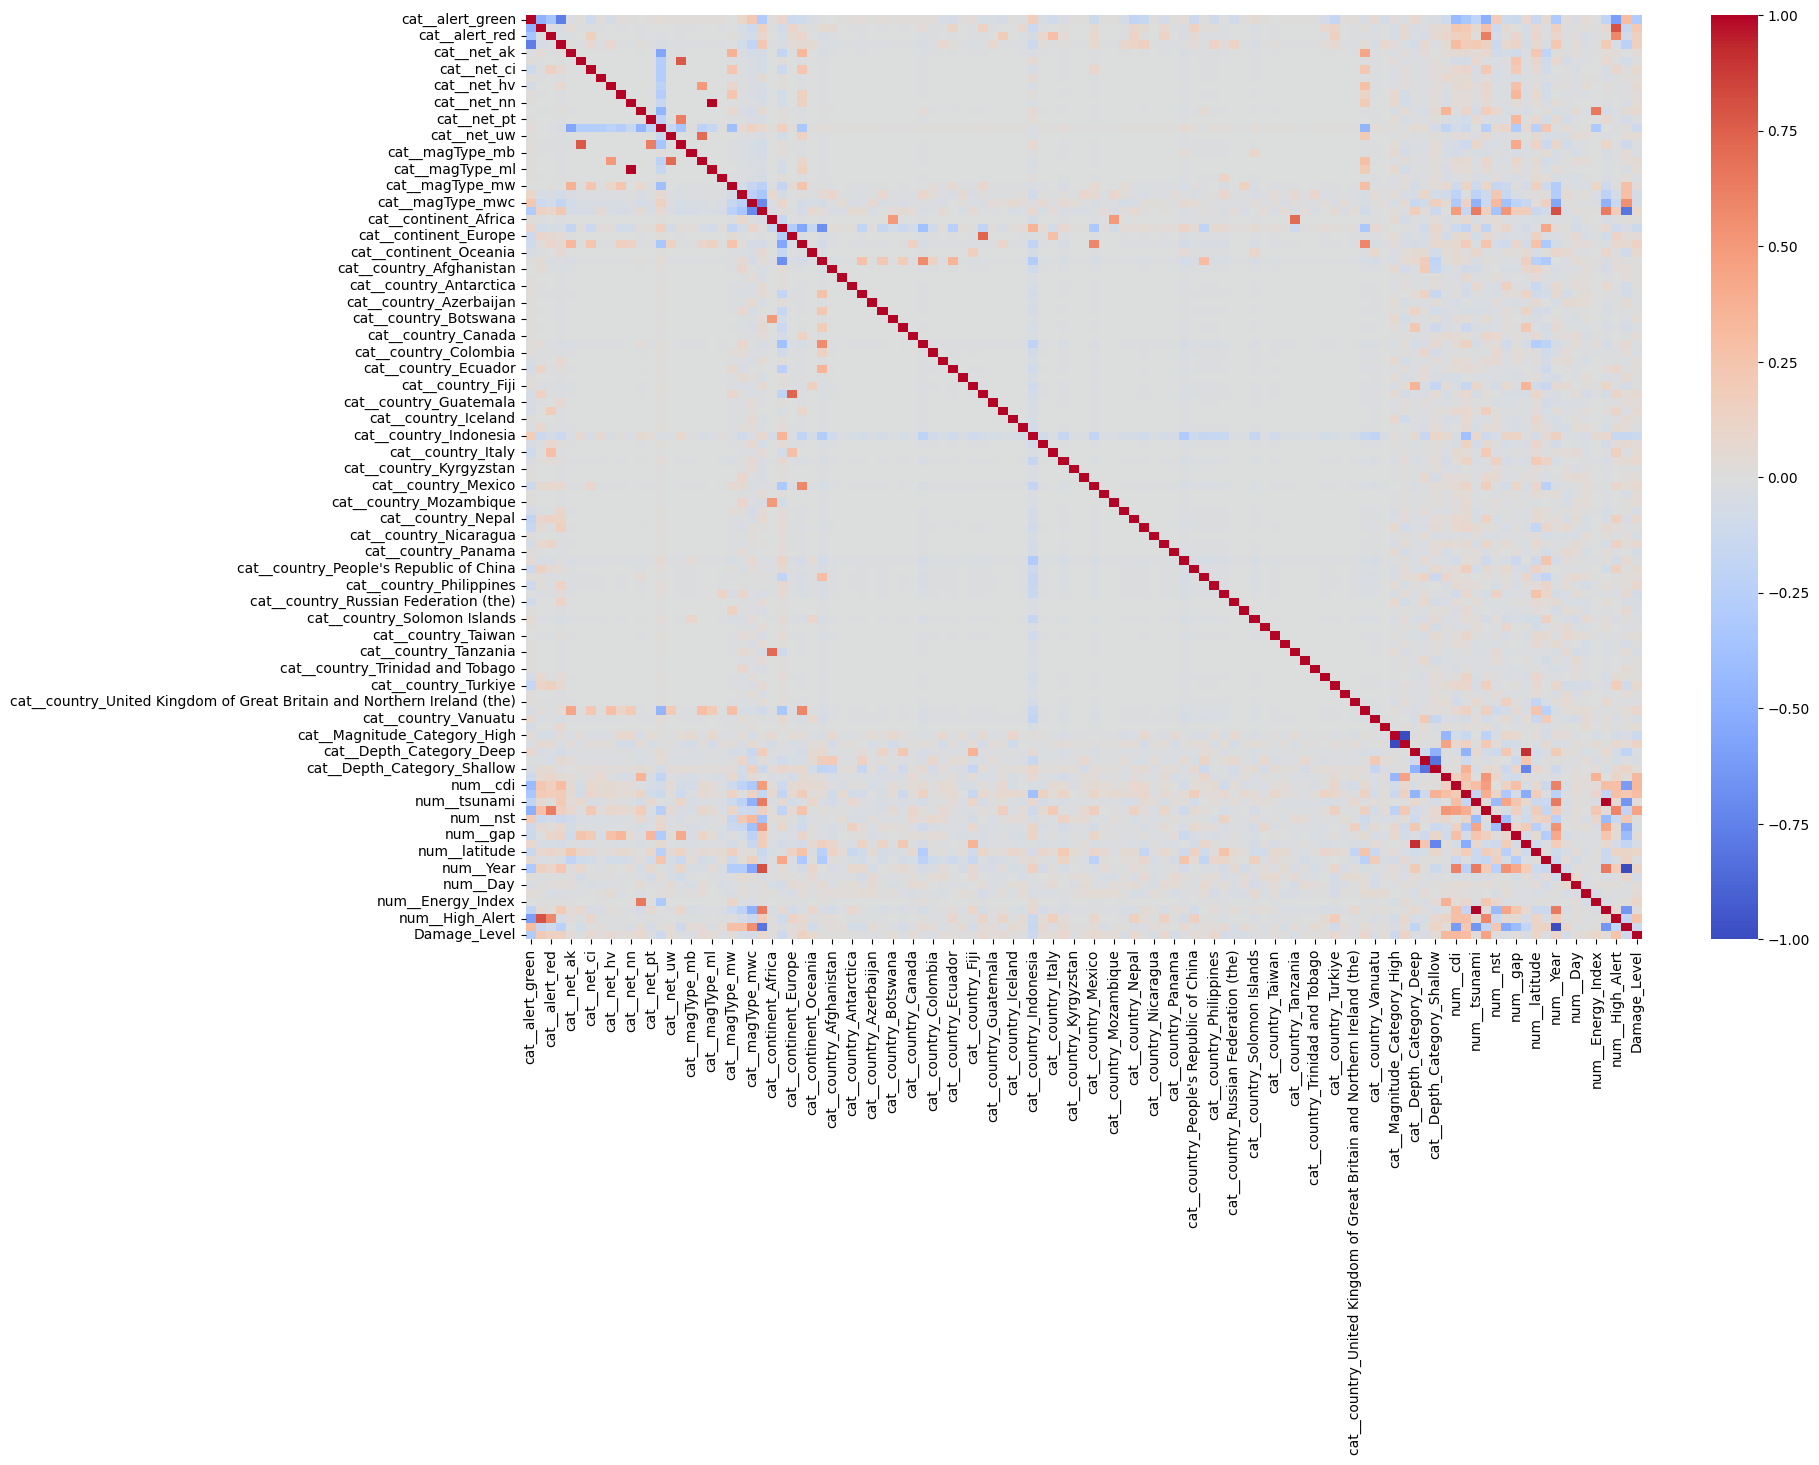

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

In [254]:
processed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cat__alert_green,1000.0,9.040000e-01,0.294739,0.000000,1.000000,1.000000,1.000000,1.000000
cat__alert_orange,1000.0,2.400000e-02,0.153126,0.000000,0.000000,0.000000,0.000000,1.000000
cat__alert_red,1000.0,1.300000e-02,0.113331,0.000000,0.000000,0.000000,0.000000,1.000000
cat__alert_yellow,1000.0,5.900000e-02,0.235743,0.000000,0.000000,0.000000,0.000000,1.000000
cat__net_ak,1000.0,1.300000e-02,0.113331,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
num__Energy_Index,1000.0,-1.065814e-17,1.000500,-0.106398,-0.105297,-0.101544,-0.087864,21.093410
num__Tsunami_Flag,1000.0,0.000000e+00,1.000500,-0.693889,-0.693889,-0.693889,1.441153,1.441153
num__High_Alert,1000.0,5.684342e-17,1.000500,-0.196014,-0.196014,-0.196014,-0.196014,5.101669
num__Years_Ago,1000.0,-1.136868e-16,1.000500,-1.582253,-0.854278,-0.126304,0.844329,1.814962


In [255]:
processed_df.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.985112,1.582253,0.40483,0.083822,0.013187,-0.106398,-0.693889,-0.196014,-1.582253,0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.189010,1.582253,0.11792,0.438001,-1.725784,-0.106398,-0.693889,-0.196014,-1.582253,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.037814,1.582253,0.11792,0.201882,-1.291041,-0.105297,-0.693889,-0.196014,-1.582253,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.807072,1.582253,0.11792,0.083822,-0.856298,-0.079118,1.441153,-0.196014,-1.582253,3
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.807898,1.582253,0.11792,0.083822,-0.856298,-0.066762,1.441153,-0.196014,-1.582253,2


In [256]:
print("""

Feature Engineering Completed Successfully

✔ Missing Values Filled

✔ New Features Created

✔ Magnitude Category

✔ Depth Category

✔ Energy Index

✔ Risk Score

✔ High Alert Feature

✔ Years Ago Feature

✔ One Hot Encoding

✔ Standard Scaling

✔ Train Test Split

✔ Saved Preprocessor

✔ Saved Label Encoder

Dataset Ready For Machine Learning.

""")



Feature Engineering Completed Successfully

✔ Missing Values Filled

✔ New Features Created

✔ Magnitude Category

✔ Depth Category

✔ Energy Index

✔ Risk Score

✔ High Alert Feature

✔ Years Ago Feature

✔ One Hot Encoding

✔ Standard Scaling

✔ Train Test Split

✔ Saved Preprocessor

✔ Saved Label Encoder

Dataset Ready For Machine Learning.


